# Transfer Learning for Critical Temperature Prediction

This notebook demonstrates how to use frozen transfer learning with FairChem to predict critical temperatures (Tc) of magnetic materials. We will use a pre-trained formation energy model (example 2) as the base model and adapt it for Tc prediction through frozen transfer learning.

## What is Transfer Learning?

Transfer learning leverages knowledge gained from training on one task (formation energy prediction) to improve performance on a related task (critical temperature prediction). This approach:

- **Reduces training time**: Start with pre-trained weights instead of random initialization
- **Improves performance**: Especially beneficial when the target dataset is small
- **Utilizes shared representations**: Both properties depend on similar atomic and structural features
- **Frozen**: Frist severl layers parameters are kept fixed during training.

## Required Files

This example uses a formation energy model as the base model for transfer learning. Please ensure you have:

- Complete the dataset preparation tutorial (Example 1). Please copy `set_example_trainTL` obtained from Example 1 to this folder. This contains the critical temperature dataset with train/validation/test splits.
- Complete the formation energy model training tutorial (Example 2).

The base model should be located in the results directory from the formation energy training tutorial.

Let's begin by importing the necessary libraries:

In [1]:
import json
import os
import time

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from ase import Atoms
import yaml

from fairchem.core.common.tutorial_utils import fairchem_main

from fairchem.core.datasets import LmdbDataset
from sklearn.metrics import r2_score, mean_absolute_error

/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Utility Function: Result Collection

This is the same helper function used in previous tutorials to collect and organize prediction results for analysis:

In [2]:
def collect_result(dft_path, prd_path, target, application=False):
    '''
    dft_path: input test set (lmdb format).
    prd_path: test prediction output, file name is ocp_predictions.npz 
    target  : target property name in lmdb
    application: Ture if the trained model is used for application.
                 False if it is used to collect output of test result.
    '''
    dft_raw = LmdbDataset({"src": dft_path})
    prd_raw = np.load(prd_path)
    # prd_raw.files

    if not application:
        dft = np.array([data[target] for data in dft_raw])
    
    # get ml result from output
    ids = [int(i.split('_')[1]) for i in prd_raw['ids']]
    inverse_ids = np.argsort(ids)
    prd = np.array([i[0] for i in prd_raw['energy']])
    prd = prd[inverse_ids]
    
    # create pandas dataframe
    dataset = LmdbDataset({"src": dft_path})
    data_list = []
    for ind, data in enumerate(dataset):
        # Customize keys depending on what's in each data sample
        row = {
            "id":     data.id,
            'UUID':   data.UUID,
            target + "_ML" : prd[ind],
        }
        if not application:
            row[target + "_DFT"] = dft[ind]
            # row[target + "_ML" ] = data[target]
            
        data_list.append(row)
    
    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    
    return df

## 1. Configuration for Transfer Learning

The config file for this example is `config_Tc_TL.yml`. This file is similar to the formation energy model configuration but includes specific settings for transfer learning and targets Tc instead of formation energy.

### Frozen Transfer Learning Configuration

To use frozen transfer learning, specify the number of frozen layers in the config file using the `FL` flag in the `optim` section.

**How It Works:**
- **Frozen layers**: Keep their weights unchanged during training (preserve learned representations)
- **Trainable layers**: Adapt to the new task 

In this example:
- **Base model**: 5-layer formation energy model
- **Frozen layers**: First 2 layers (general atomic representations)
- **Trainable layers**: Last 3 layers (task-specific adaptations)

Configuration example:
```yaml
optim:
  FL: 2  # Freeze the first 2 layers
```

#### Alternative: Command Line Configuration

The frozen layer number can also be set directly in the command line when starting training using the `--optim.FL` flag, which overrides the config file setting.

Command line example:
```bash
python main.py --mode train --config-yml config_Tc_TL.yml --optim.FL=2 --checkpoint base_model.pt
```

## 2. Tc Model Training Using Transfer Learning

#### Setup
Define the output directory, job_name, configuration file path, and log names.

In [3]:
run_dir = f"result_Tc"   

job_name='Tc_TL'   

config    = f"./config_{job_name}.yml"
log_file  = f"log_train_{job_name}.txt"
warn_file = f"warn_train_{job_name}.txt"

#### Specify Base Model for Transfer Learning

The `checkpoint` variable points to the checkpoint from the formation energy training (Example 2). You need to update this path to match your trained model location. This is the base model used for transfer learning.

In [ ]:
# the base model for TL
# please change this to the trained model in example 2.
checkpoint = '../2_train_scratch_formE/result_Form/checkpoints/2025-10-11-11-31-28-Form_scratch/checkpoint.pt'

#### Start Transfer Learning Training

The training command includes the `--checkpoint` flag to specify the base model checkpoint for transfer learning.

In [5]:
t0 = time.time()
! CUDA_VISIBLE_DEVICES={2}  \
python {fairchem_main()} --mode train --config-yml {config}           \
                         --run-dir {run_dir}  --identifier {job_name} \
                         --print-every 50 \
                         --checkpoint {basemodel}  \
                         > {log_file} 2>  {warn_file}
print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

Elapsed time = 1639.0 seconds


#### 💡  **Key Transfer Learning Parameters:**
- `--checkpoint {basemodel}`: Loads the pre-trained formation energy model
- The frozen layers (FL=2) are specified in the config file
- Training adapts only the unfrozen layers for the new task

### Extract Transfer Learning Model Path

After training completes, locate the checkpoint directory for the trained model.

In [9]:
# Obtain output dir for later convenience.
# This dir contains trained model (checkpoint).  
cpline = !grep "checkpoint_dir:" {log_file}
cpdir  = cpline[0].split(':')[-1].strip()
print(cpdir)

result_Tc/checkpoints/2025-10-11-18-57-20-Tc_TL


Copy the configuration file to the checkpoint directory for future reference.

In [10]:
# copy config file to the ouput dir for future need.
! cp {config} {cpdir}'/config.yml'

## 3. Evaluate Performance

#### Collect Prediction Results

We use the `collect_result` function to collect test results, just like in previous examples.

In [12]:
dft_path = "set_example_trainTL/test.lmdb" 
prd_path = cpdir.replace('checkpoints', 'results')  +'/ocp_predictions.npz'
print('Path to test set used for training: ', dft_path)
print('Path to test prediction by ML: ',      prd_path)

df = collect_result(dft_path, prd_path, target='Tc', application=False)
df.to_csv('./performance_test_MLIP.csv')


Path to test set used for training:  set_example_trainTL/test.lmdb
Path to test prediction by ML:  result_Tc/results/2025-10-11-18-57-20-Tc_TL/ocp_predictions.npz


In [13]:
# the top 4 rows.
df.head(4)

,id,UUID,Tc_ML,Tc_DFT
0,104693,2abc4d30-11e6-45e4-9937-24be12f965a5,17.15625,0.0
1,19519,f3303db4-c9bb-4970-8b35-0e410932dd83,476.25000,540.6
2,16402,d7be146b-5da3-4875-9da6-319abce48ec6,68.18750,0.5
3,13358,261382e9-91ad-48cf-99e0-efc0b5d825b1,579.50000,749.8


#### Performance Visualization

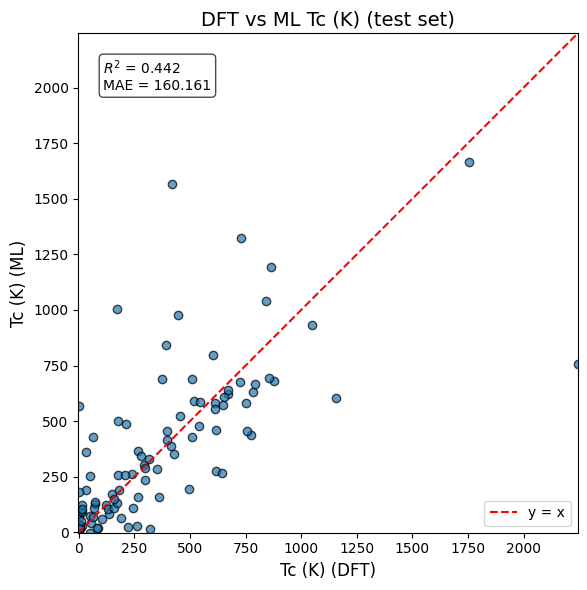

In [16]:
df = pd.read_csv('performance_test_MLIP.csv', index_col=0)
target = 'Tc'

# Compute metrics
r2 = r2_score(df[target+'_DFT'], df[target+'_ML'])
mae = mean_absolute_error(df[target+'_DFT'], df[target+'_ML'])

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(df[target+'_DFT'], df[target+'_ML'], alpha=0.7, edgecolor='k')

# 1:1 line
lims = [
    min(df[target+'_DFT'].min(), df[target+'_ML'].min()),
    max(df[target+'_DFT'].max(), df[target+'_ML'].max())
]
plt.plot(lims, lims, 'r--', label='y = x')

# Labels, title
plt.xlabel("Tc (K) (DFT)", fontsize=12)
plt.ylabel("Tc (K) (ML)", fontsize=12)
plt.title("DFT vs ML Tc (K) (test set)", fontsize=14)

# Same scale for x and y
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

# Add metrics as text inside plot
plt.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}",
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.legend()
plt.tight_layout()
plt.savefig('fig_performance_TL.png')
plt.show()


## Application

Applying the trained model to predict Tc for new compounds follows the same procedure as in Example 2; therefore, those steps are omitted here.